- A Namespace is a way to logically divide a Kubernetes cluster into separate virtual environments.
- A Pod is a wrapper around one or more containers that share network, storage, and lifecycle in Kubernetes.
- A Kubernetes cluster is a group of nodes managed by a control plane to run containerized applications.
- A Node is simply a machine that does the actual work of running our application
    - Cluster: The whole system
    - Control Plane: The brain
    - Node: The worker 

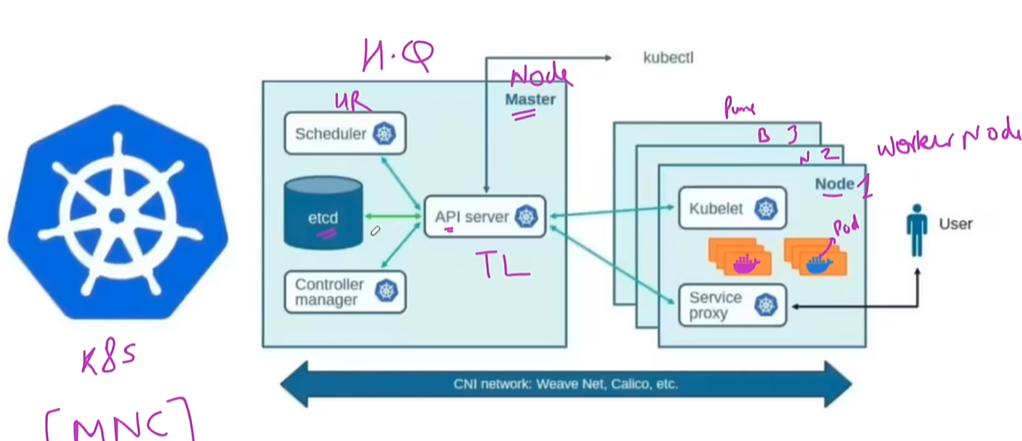

1. etcd is a distributed key-value store used to store critical data for distributed systems.
2. Control Plane and worker node communicates via CNI (Container network interface)
3. Kubeadm, Minikube, kind, and EKS—are all ways to create or run a Kubernetes cluster
    - Kubeadm: kubeadm is a tool provided by Kubernetes to bootstrap (set up) a cluster manually.
    - Minikube: Minikube runs a single-node Kubernetes cluster on your laptop.
    - Kind: It runs Kubernetes clusters inside Docker containers instead of VMs.
    - EKS(Elastic Kubernetes Service): Amazon EKS is a fully managed Kubernetes service by Amazon Web Services.
  
| Tool     | What it is                | Best for            |
| -------- | ------------------------- | ------------------- |
| kubeadm  | Cluster setup tool        | Real clusters (DIY) |
| Minikube | Local single-node cluster | Learning            |
| kind     | Kubernetes in Docker      | Testing / CI        |
| EKS      | Managed Kubernetes        | Production          |


  
| Feature          | kubeadm      | Minikube | kind   | EKS       |
| ---------------- | ------------ | -------- | ------ | --------- |
| Setup complexity | High         | Very low | Low    | Very low  |
| Environment      | Real servers | Local VM | Docker | AWS cloud |
| Multi-node       | Yes          | Limited  | Yes    | Yes       |
| Production use   | Yes          | No       | No     | Yes       |
| Speed            | Medium       | Medium   | Fast   | Depends   |


- **Kind-Cluster**:
    - It runs K8 clusters inside docker container insteads of VMs.
    - Firstly Create a config.yml file to setup a cluster
    ```bash
        kind: Cluster
        apiVersion: kind.x-k8s.io/v1alpha4

        nodes:
        - role: control-plane
            image: kindest/node:v1.31.2
        - role: worker
            image: kindest/node:v1.31.2
        - role: worker
            image: kindest/node:v1.31.2
        - role: worker
            image: kindest/node:v1.31.2
            extraPortMappings:
            - containerPort: 80
                hostPort: 80
                protocol: TCP
            - containerPort: 443
                hostPort: 443
                protocol: TCP
    ```
    - Then write 
    ``` bash
        kind create cluster --name=<name_of_cluster> --config=config.yml
    ```
    - To check use
    ``` bash
        kubectl cluster-info --context kind-tws-cluster
    ```
    - To see all nodes
    ``` bash
        kubectl get nodes
    ```

- **Minikubes:**
    - This runs a single cluster on our machine
    - To create a cluster type
    ```bash
       minikube start --driver=docker (add --vm=true for virtual machine like ec2)
    ```

- To switch to a particular cluster
    ```bash
        kubectl config use-context <Cluster_name>
    ```
- To check the current cluster
    ``` bash
        kubectl config current-context
    ```
- To check the all cluster
    ``` bash
        kubectl config get-contexts
    ```

- Taint: means restricting everything to access a particular working node, 
```bash
    1. kubectl taint node tws-cluster-worker2 prod=true:NoSchedule
    2. kubectl taint node tws-cluster-worker2 prod=true:NoSchedule- (this will untaint it)
```
- Also, control-plane is also Tainted by default
- If still you wantend to run things on a tainted node then add below command in that .yml file
```bash
    spec:
        tolerations:
            - key: "prod"
            operator: "Equal"
            value: "true"
            effect: "NoSchedule"
```

- For memory usage
``` bash
    kubectl top pod/node/...
```
-  Creating a custom load generator
``` bash
    kubectl run -it load-generator --image=busybox -n <namespace> /bin/sh
```
    - It will open a bash terminal then type
``` bash
    while true; do wget -q -O- https://<service_name>.<namespace>.svc.cluster.local; done
```

- RBAC (Role based access control)


- ***Custom Resource Defination (CRDs):*** this allows us to create a custome resource in K8s
- **Helm** is a package manager for K8s, it does all our manual work of creating all files
```bash
    helm create <name-service> # This will create all files for this particular service
    helm package <name-service>/ # after filling the necessary details in values.yml file in <name-service> it will create a package of it
    helm install <custom-name> <name-service>  # This will create and run all the files inside it in default namespace
    helm uninstall <custom-name> # This will delete all this
    helm install <custom-name> <name-service> --namespace <namespace> --create-namespace # This will create for a particular namespace
```
- If we changed something in our package then firstly to update it againrun package command then
``` bash
    helm upgrade <custom-name> <name-service> -n <namespace>
```

- Now suppose you want to rollback so for this
``` bash
    helm rollback <custom-name> <revsion-no.> -n <namespace>
    (for eg.) helm rollback pord-apache 1 -n apache
```

- Istio is a service mesh that uses sidecar proxies to manage, secure, and monitor communication between microservices.
    - Istio sits between your services and controls how they talk to each other.


## Namespace

1. To view all the namespace  
``` bash
    kubectl get ns
```
2. Creating a namespace
``` bash
    kubectl create ns <namespace_name>
```
3. Creating a pod in a namespace
``` bash
    kubectl run nginx --image=nginx #(nginx is the name of the namespace and image but it's for default)
    kubectl run nginx --image=nginx -n nginx # ( and it's for a particular name space)
```
4. Deleting a pod
``` bash
    kubectl delete pod nginx
```
5. Viewing all pod
``` bash
    kubectl get pods # For default namespace 
    kubectl get pods -n <namespace> # For a particular namespace 
```
6. Deleting a namespace
``` bash
    kubectl delete ns nginx (also delete every thing inside this namespace)
```
7. Doing all this in one yml file
``` bash
    vim filename.yml
    kubectl apply -f name
```
8. Debugging the running pod details
``` bash
    kubectl describe pod/nginx-pod -n nginx
```
9. entering into a pod
``` bash
    kubectl exec -it pod/nginx-pod -n nginx -- bash
```
10. After creating a deployment file of a pod we can easily increase the replicas of pods via
``` bash
    kubectl scale deployment/nginx-deployment -n nginx --replicas=1
```